#### Making the WordCloud and analysing this

In [2]:
#Importing libraries
import pandas as pd
import requests
import time
from wordcloud import WordCloud 
from collections import Counter
import matplotlib.pyplot as plt
import re


In [3]:
#loading the data and filtering this (in terms of realistic-ness)
df = pd.read_csv('evaluation_results3.csv')

df['Realistic?'] = df['Realistic?'].fillna('Yes')
df = df[df['Realistic?'].str.contains('Yes', case=False, na=False)]

print(f"Loaded {len(df)} realistic requests.")

Loaded 1412 realistic requests.


In [4]:
# extracting levels

def extract_levels(value):
    if pd.isna(value) or value == 'Original Request':
        return None, None
    if ' + ' in value:
        parts = value.split(' + ')
        if len(parts) == 2:
            seniority = parts[0].strip().title()
            raw_hastiness = parts[1].strip().title().split('(')[0].strip()
            
            if 'Very Hasty' in raw_hastiness:
                hastiness = 'Very Hasty'
            elif 'Hasty' in raw_hastiness:
                hastiness = 'Hasty'
            elif 'Neutral' in raw_hastiness:
                hastiness = 'Neutral'
            elif 'Formal' in raw_hastiness:
                hastiness = 'Formal'
            elif 'Very Formal' in raw_hastiness:
                hastiness = 'Very Formal'
            else:
                hastiness = raw_hastiness
            return seniority, hastiness
    return None, None

In [5]:
df['Seniority'] = df['Variation Value'].apply(lambda x: extract_levels(x)[0])
df['Hastiness'] = df['Variation Value'].apply(lambda x: extract_levels(x)[1])
df = df.dropna(subset=['Hastiness'])

print(f"Rows with hastiness: {len(df)}")


Rows with hastiness: 1308


In [6]:
#cleaning text (removing stopwords)
STOPWORDS = set([
    'to', 'for', 'the', 'of', 'and', 'in', 'on', 'at', 'with', 'by', 'from', 
    'as', 'is', 'was', 'we', 'our', 'us', 'i', 'you', 'this', 'that', 
    'these', 'those', 'a', 'an', 'data', 'access', 'request', 'will', 'can',
    'use', 'used', 'using', 'analysis', 'analyze', 'help', 'make', 'need',
    'would', 'could', 'should', 'may', 'might', 'must', 'shall', 'also',
    'well', 'better', 'good', 'great', 'really', 'very', 'even'
])

def clean_text(text):
    if not isinstance(text, str):
        return []
    text = text.lower()
    words = re.findall(r'\b[a-z]+\b', text)
    return [w for w in words if w not in STOPWORDS and len(w) > 2]

df['Clean_Words'] = df['Purpose'].apply(clean_text)


In [7]:
def get_ngrams_freq(word):
    """Query NGRAMS API for relative frequency of a word in English."""
    try:
        url = f"https://api.ngrams.dev/eng/search?query={word}&flags=cr"
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            data = response.json()
            if data.get('ngrams'):
                return data['ngrams'][0].get('relTotalMatchCount', 0)
    except Exception as e:
        pass
    return 0

In [8]:
all_words = [w for words in df['Clean_Words'] for w in words]
unique_words = list(set(all_words))

print(f"Fetching baseline frequencies for {len(unique_words)} words...")
ngram_baseline = {}
for i, word in enumerate(unique_words):
    if i % 20 == 0:
        print(f"Progress: {i}/{len(unique_words)}")
    ngram_baseline[word] = get_ngrams_freq(word)
    time.sleep(0.15)

Fetching baseline frequencies for 2370 words...
Progress: 0/2370
Progress: 20/2370
Progress: 40/2370
Progress: 60/2370
Progress: 80/2370
Progress: 100/2370
Progress: 120/2370
Progress: 140/2370
Progress: 160/2370
Progress: 180/2370
Progress: 200/2370
Progress: 220/2370
Progress: 240/2370
Progress: 260/2370
Progress: 280/2370
Progress: 300/2370
Progress: 320/2370
Progress: 340/2370
Progress: 360/2370
Progress: 380/2370
Progress: 400/2370
Progress: 420/2370
Progress: 440/2370
Progress: 460/2370
Progress: 480/2370
Progress: 500/2370
Progress: 520/2370
Progress: 540/2370
Progress: 560/2370
Progress: 580/2370
Progress: 600/2370
Progress: 620/2370
Progress: 640/2370
Progress: 660/2370
Progress: 680/2370
Progress: 700/2370
Progress: 720/2370
Progress: 740/2370
Progress: 760/2370
Progress: 780/2370
Progress: 800/2370
Progress: 820/2370
Progress: 840/2370
Progress: 860/2370
Progress: 880/2370
Progress: 900/2370
Progress: 920/2370
Progress: 940/2370
Progress: 960/2370
Progress: 980/2370
Progress

In [ ]:
# Calculating the Lift score
def get_lift_words(df, group_value, baseline, top_n=15):
    group_df = df[df['Hastiness'] == group_value]
    group_words = [w for words in group_df['Clean_Words'] for w in words]
    group_counter = Counter(group_words)
    total_group_words = len(group_words)
    
    scores = {}
    for word, count in group_counter.items():
        actual_freq = count / total_group_words if total_group_words > 0 else 0
        expected_freq = baseline.get(word, 1e-12)
        if expected_freq > 0 and actual_freq > 0:
            scores[word] = actual_freq / expected_freq
    
    sorted_words = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return sorted_words

hasty_lift = get_lift_words(df, 'Very Hasty', ngram_baseline)
formal_lift = get_lift_words(df, 'Very Formal', ngram_baseline)

AttributeError: 'list' object has no attribute 'items'

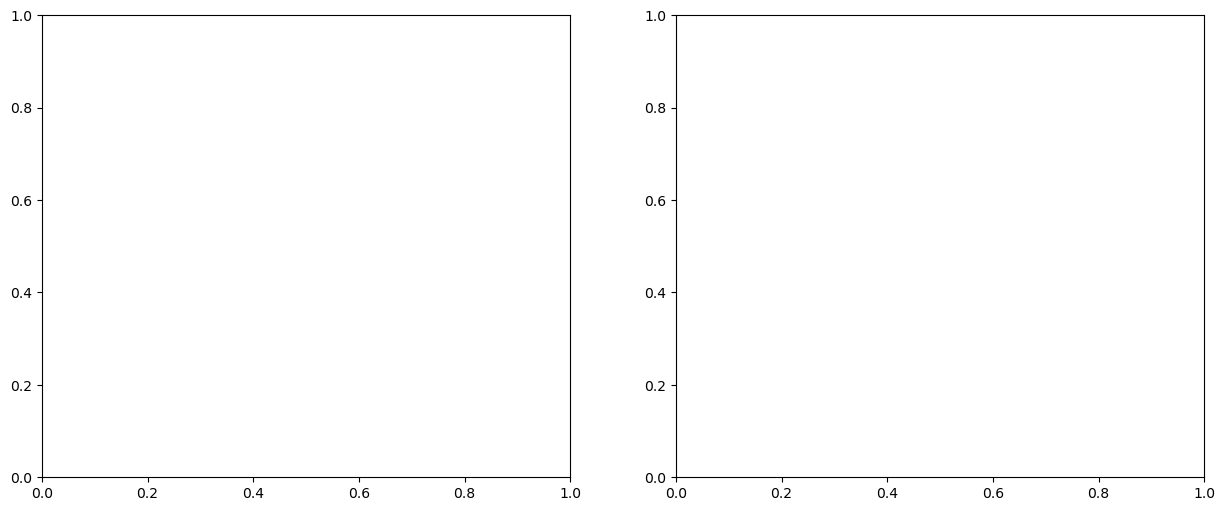

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

if hasty_lift:
    wc1 = WordCloud(
        width=400, height=300, 
        background_color='white', 
        colormap='Reds', 
        max_words=30
    )
    wc1.generate_from_frequencies(hasty_lift)
    axes[0].imshow(wc1, interpolation='bilinear')
    axes[0].axis('off')
    axes[0].set_title('Words OVERUSED in "Very Hasty" Requests\n(Lift Score = Actual / Expected)', fontsize=12)

if formal_lift:
    wc2 = WordCloud(
        width=400, height=300, 
        background_color='white', 
        colormap='Blues', 
        max_words=30
    )
    wc2.generate_from_frequencies(formal_lift)
    axes[1].imshow(wc2, interpolation='bilinear')
    axes[1].axis('off')
    axes[1].set_title('Words OVERUSED in "Very Formal" Requests\n(Lift Score = Actual / Expected)', fontsize=12)

plt.tight_layout()
plt.show()